# 05 - baseline model

we've got `features_v1.parquet` from notebook 04 - one row per user with demographics, payment history, and listening activity, plus the `is_churn` label.

now let's actually train something. the plan:
- split the data into a training set and a validation set
- train a baseline LightGBM model
- check how good it is using log loss (the actual metric for this competition) and AUC
- compare against a "naive" baseline so we know if the model is actually helping
- take a quick look at which features matter most

## Step 1: load the feature table

just reading back the file we saved at the end of notebook 04.

In [1]:
import pandas as pd
from pathlib import Path

PROCESSED = Path("../data/processed")

df = pd.read_parquet(PROCESSED / "features_v1.parquet")
print(df.shape)
df.head()

(970960, 23)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,num_transactions,total_actual_paid,total_plan_list_price,...,last_expire_date,num_days,num_25_sum,num_50_sum,num_75_sum,num_985_sum,num_100_sum,num_unq_sum,total_secs_sum,total_secs_mean
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,0.0,0.0,0.0,...,NaT,11.0,186.0,23.0,13.0,10.0,318.0,348.0,80598.557,7327.141545
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,1.0,180.0,180.0,...,2017-04-11,6.0,0.0,4.0,2.0,0.0,26.0,30.0,6986.509,1164.418167
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,2.0,300.0,300.0,...,2017-06-15,20.0,239.0,57.0,32.0,22.0,205.0,432.0,67810.467,3390.523350
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,unknown,7.0,20140109.0,10.0,1490.0,1490.0,...,2018-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,8.0,792.0,792.0,...,2017-09-18,15.0,9.0,7.0,4.0,4.0,962.0,548.0,239882.241,15992.149400


## Step 2: pick our features and target

`is_churn` is what we're trying to predict - that's `y`. everything else is a feature, with a few exceptions:

- `msno` -> just the user id, not useful as a feature
- `last_transaction_date` and `last_expire_date` -> these are dates. LightGBM can't use raw dates directly, so for this baseline we'll just leave them out. (turning them into something like "days since last transaction" would make a good feature later, but keeping it simple as of now)

A few columns are categories rather than plain numbers - `city`, `gender`, and `registered_via`. LightGBM can handle categorical columns natively, so we need to tell pandas they're `category` dtype.

In [2]:
target = 'is_churn'
drop_cols = ['msno', 'is_churn', 'last_transaction_date', 'last_expire_date']
cat_cols = ['city', 'gender', 'registered_via']

X = df.drop(columns=drop_cols)
y = df[target]

for col in cat_cols:
    X[col] = X[col].astype('category')

print(X.shape, y.shape)
X.dtypes

(970960, 19) (970960,)


city                      category
bd                         float64
gender                    category
registered_via            category
registration_init_time     float64
num_transactions           float64
total_actual_paid          float64
total_plan_list_price      float64
is_cancel_sum              float64
is_auto_renew_mean         float64
num_days                   float64
num_25_sum                 float64
num_50_sum                 float64
num_75_sum                 float64
num_985_sum                float64
num_100_sum                float64
num_unq_sum                float64
total_secs_sum             float64
total_secs_mean            float64
dtype: object

## Step 3: train/validation split

We'll hold out 20% of the data to check how well the model does on new user data.

Only about 9% of users churn, so this is an imbalanced problem. `stratify=y` makes sure both the training and validation sets keep roughly that same ~9% churn rate - otherwise a random split could by chance leave us with a validation set that looks quite different from the training set.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("train:", X_train.shape, "churn rate:", round(y_train.mean(), 4))
print("val:  ", X_val.shape, "churn rate:", round(y_val.mean(), 4))

train: (776768, 19) churn rate: 0.0899
val:   (194192, 19) churn rate: 0.0899


## Step 4: train a baseline LightGBM model

Just `LGBMClassifier` with its default settings, fit on the training set. this is our baseline

LightGBM picks up the `category` dtype columns automatically (no need to one-hot encode them), and it handles missing values (`NaN`) in numeric columns on its own , so we don't need to fill in `bd`, `city`, etc.

In [5]:
import lightgbm as lgb

model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2991
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Step 5: evaluate

Submissions in the competition to be scored using **log loss** - this penalizes confident *wrong* predictions much more harshly than cautious ones, so it cares about predicted probabilities, not just whether the predicted class is right. we'll also check **AUC**, a common measure of how well the model ranks churners above non-churners.

Then, we compare against a "naive" baseline: just predicting the overall churn rate (~9%) for every single user, regardless of who they are. If our model can't beat that, it isn't learning anything useful.

In [6]:
from sklearn.metrics import log_loss, roc_auc_score

val_preds = model.predict_proba(X_val)[:, 1]

naive_preds = [y_train.mean()] * len(y_val)

print("naive log loss:", round(log_loss(y_val, naive_preds), 5))
print("model log loss:", round(log_loss(y_val, val_preds), 5))
print()
print("model AUC:     ", round(roc_auc_score(y_val, val_preds), 5))

naive log loss: 0.3024
model log loss: 0.08442

model AUC:      0.98003


## Step 6: features that matter the most

LightGBM keeps track of how often each feature was used to split the data while building its trees - `feature_importances_`.

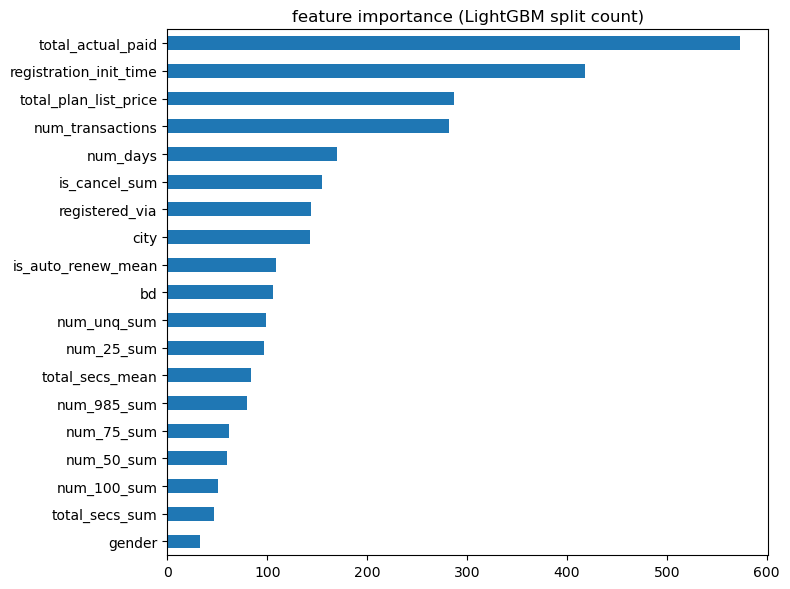

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values()

importances.plot(kind='barh', figsize=(8, 6))
plt.title("feature importance (LightGBM split count)")
plt.tight_layout()
plt.show()

## Step 7: save the model

saving the trained model so it can be reused later (e.g. from the API) without retraining.

In [8]:
import joblib

MODELS = Path("../models")
MODELS.mkdir(exist_ok=True)

joblib.dump(model, MODELS / "lgbm_baseline.pkl")
print("saved:", MODELS / "lgbm_baseline.pkl")

saved: ../models/lgbm_baseline.pkl
